# 특성 추출 기법

## 1. 라이브러리 호출

In [26]:
!pip install opencv-python

- OpenCV : Open Source Computer Vision Library : 오픈 소스 컴퓨터 비전 라이브러리


In [27]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

- torchvision : 컴퓨터 비전 용도의 패키지
- torchvision.transforms : 데이터 전처리를 위해 사용되는 패키지
- torchvision.models : 다양한 파이토치 네트워크를 사용할 수 있도록ㄷ 도와주는 패키지

## 2. 이미지 데이터 전처리 방법 정의

In [28]:
from google.colab import files
import zipfile
import os

# 파일 업로드 받기
uploaded = files.upload()  # zip 파일 업로드 창이 뜹니다.

# 업로드된 파일의 이름 얻기
filename = next(iter(uploaded))

# 압축 풀기
if filename.endswith(".zip"):
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall("/content/catanddog")  # 원하는 경로로 압축 해제

Saving catanddog.zip to catanddog (1).zip


In [29]:
# 경로 설정
data_path = "/content/catanddog/train"  # 여기에 압축된 폴더 구조에 따라 경로 조정 가능


transform = transforms.Compose(
    [
      transforms.Resize([256,256]),
      transforms.RandomResizedCrop(224),
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor()
])

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


- **torchvision.transform**
  - 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환해줌
  - Resize([256],[256]) : 이미지의 데이터의 크기를 256 X 256로 조정
    - 용도 : 합성곱층을 통과하기 위해 이미지 크기를 조정하는 전처리 과정
  - RandomResizedCrop(244) : 이미지를 랜덤한 크기 및 비율로 자름
    - 용도 : 데이터 확장 -> 이미지를 랜덤한 비율로 자른 후 데이터 크기를 조정

  - RandomHorizontalFlip : 이미지를 랜덤하게 수평으로 뒤집음
  - ToTensor : 이미지 데이터를 텐서로 변환

---
- **datasets.ImageFolder** : 데이터로더가 데이터를 불러올 대상(혹은 경로)와 방법(transform, 전처리)을 정의
  - data_path : 불러올 데이터가 위치한 경로
  - transform : 이미지 데이터에 대한 전처리

---
- **DataLoader** : 데이터를 불러오는 부분
  - train_dataset : 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당
  - batch_size : 한 번에 불러올 데이터양을 결정
  - num_workers : 데이터를 불러올 때 하위 프로세를 몇 개 사용할 지 설정
    - 너무 많은 하위 프로세스 설정 시 : 오류 및 메모리 부족
  - shuffle : 데이터를 무작위로 섞어서 랜덤으로 불러옴
    

## 3. 학습에 사용될 이미지 출력

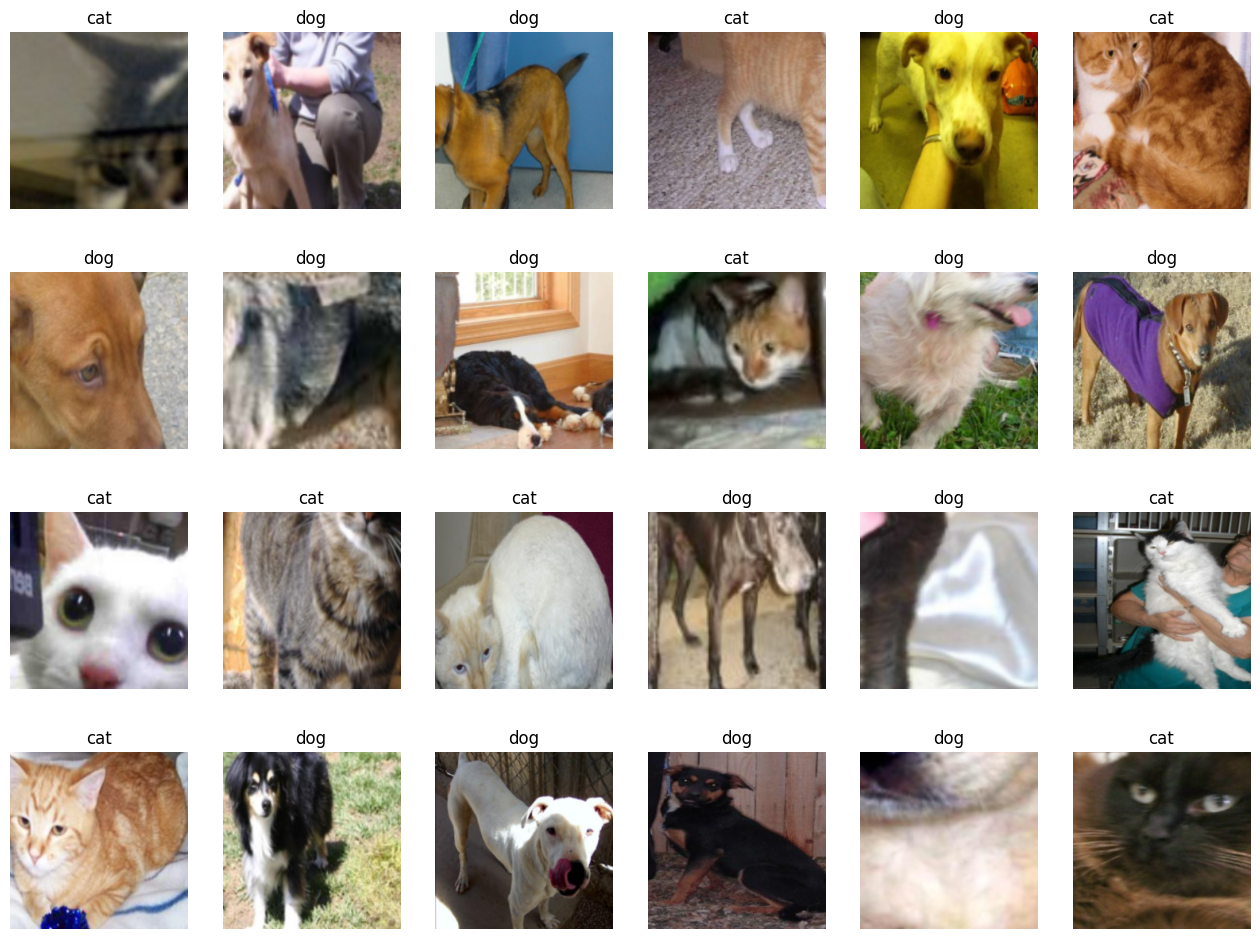

In [30]:
import numpy as np

samples, labels = next(iter(train_loader))
classes = {0:'cat',1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))

for i in range(24): # 24개의 이미지 데이터 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

- **next(iter(train_loader))**
 - **iter()** : 반복 가능한 객체(iterable)에서 반복자(iterator)를 꺼내주는 함수
    - train_loader는 여러 배치를 담고 있는 iterable
    - iter(train_loader) = 첫 번째 배치를 꺼낼 준비가 된 반복자가 만들어짐

  - **next()** : 위에서 만든 반복자에서 실제 데이터를 하나 꺼내주는 함수
    - next(iter(train_loader)) = train_loader에서 첫 번째 배치를 가져옴

  - 즉, iter()로 반복자를 구하고, 그 반복자를 next()에 전달하여 차례대로 꺼낼 수 있음

  - train_loader(배치 데이터들을 담은 DataLoader)에서 한 번만 데이터를 꺼내서, 그걸 samples(입력 이미지), labels(정답 레이블)에 저장하겠다.
---
- **np.transpose** : 행과 열을 바꿈으로 행렬의 차원을 바꾸어줌
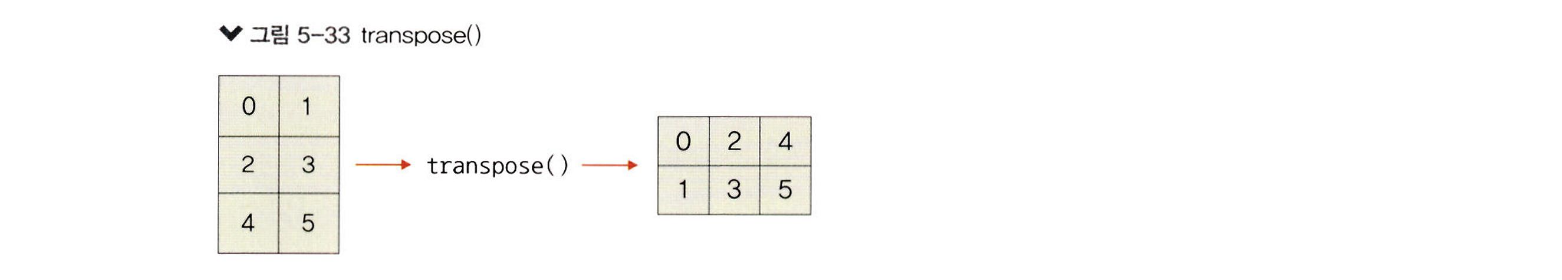
  - A와 B의 행과 열의 수가 달라 내적이 불가능할 경우 : np.transpose() 혹은 np.reshape()등으로 차원 조정 필요
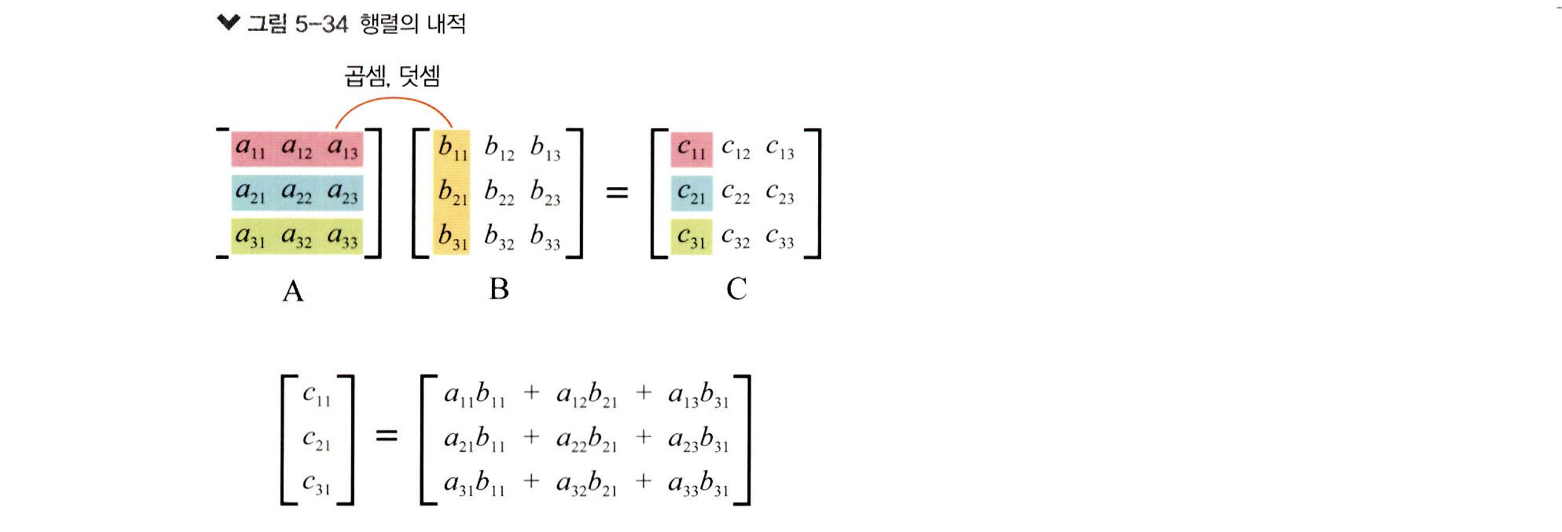
  - np.transpose(samples[i].numpy(), (1,2,0))을 사용하여 (244,244,3)과 같은 형태로 변환 후 사용해야함


## 4. 사전 훈련된 모델(ResNet18) 내려받기

In [31]:
resnet18 = models.resnet18(pretrained=True) #pretrained=True : 사전 학습된 가중치를 사용하겠다.

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### ResNet18
- 50개의 계층으로 구성된 합성곱 신경망
- ImageNet DB의 100만 개가 넘는 영상을 이용하여 훈련된 신경망
- 전이 학습에 사용되도록 사전 훈련된 모델을 제공

- 하지만, 입력 제약이 매우 크고, 충분한 메모리(RAM)이 없으면 학습 속도가 느릴 수 있음

#### Pretrained model : 사전 학습된 모델

In [ ]:
# Pytorch : 무작위 가중치로 모델 구성하는 방법
import torchvision.models as models

resnet18 = models.resnet18()
alexnet = models. alexnet()
vgg16 = models.vgg16()
squeezenet = models. squeezenet1_00
densenet = models. densenet161 )
inception = models. inception_v3()
googlenet = models.googlenet( )
shufflenet = models.shufflenet_v2_x1_0()
mobilenet_v2 = models.mobilenet_v2()
mobilenet_v3_large = models.mobilenet_v3_large()
mobilenet_v3_small = models.mobilenet_v3_small()
resnext50_32x4d = models.resnext50_32x4d()
wide_resnet50_2 = models.wide_resnet50_2()
mnasnet = models.mnasnet1_0()

In [ ]:
# 사전 학습된 모델(사전 학습된 모델의 가중치 값) 사용하는 방법 : pretrained = True
import torchvision.models as models
resnet18 = models.resnet18(pretrained=True)
alexnet = models.alexnet(pretrained=True)
squeezenet = models. squeezenet1_0(pretrained=True)
vgg16 = models.vgg16(pretrained=True)
densenet = models.densenet161 (pretrained=True)
inception = models.inception_v3(pretrained=True)
googlenet = models.googlenet(pretrained=True)
shufflenet = models. shufflenet_v2_x1_0(pretrained=True)
mobilenet_v2 = models.mobilenet_v2(pretrained=True)
mobilenet_v3_large = models mobilenet_v3_large(pretrained=True)
mobilenet_v3_small = models.mobilenet_v3_small (pretrained=True)
resnext50_32x4d = models.resnext50_32x4d(pretrained=True)
wide_resnet50_2 = models wide_resnet50_2(pretrained=True)
mnasnet = models.mnasnet1_0(pretrained=True)

## 5. 사전 훈련된 모델의 파라미터 학습 유무 지정
- 내려받은 ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습을 하지 않고 고정시킴

In [32]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False

set_parameter_requires_grad(resnet18)

- **param.requireds_grad = False**
  - 역전파 중 파라미터들에 대한 변화를 계산할 필요 없음
  - 모델의 일부(합성곱층 + 폴링층)을 고정하고 나머지를 학습하고자 할 때

## 6. ResNet18에 완전연결층 추가
- 내려받은 ResNet18의 마지막 부분에 FC layer(완전연결층) 추가
  - 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용
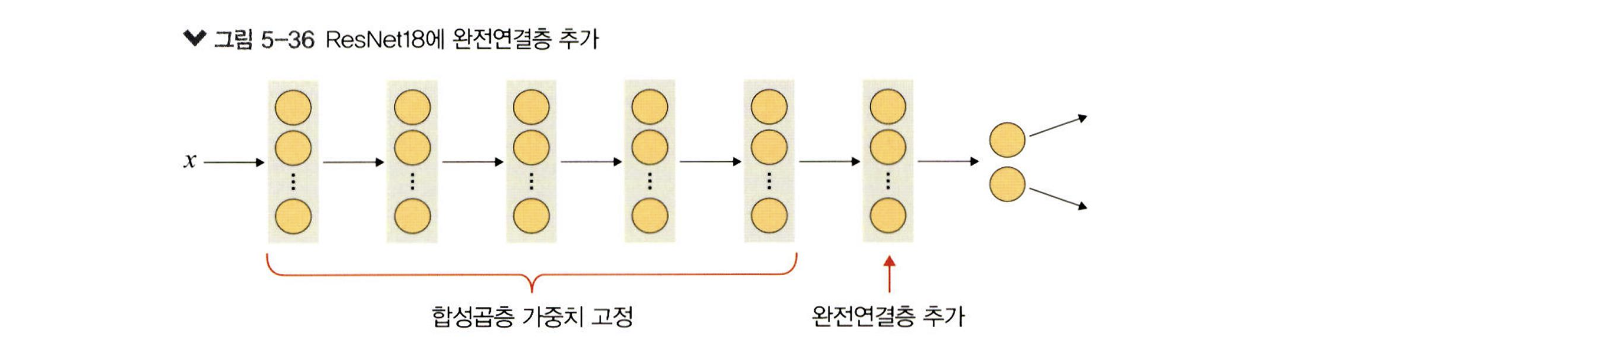

In [33]:
resnet18.fc = nn.Linear(512,2) # 2 : 클래스가 (개, 고양이) 두 개라는 의미

## 7. 모델의 파라미터 값 확인

- 파라미터 값들을 가져온 결과
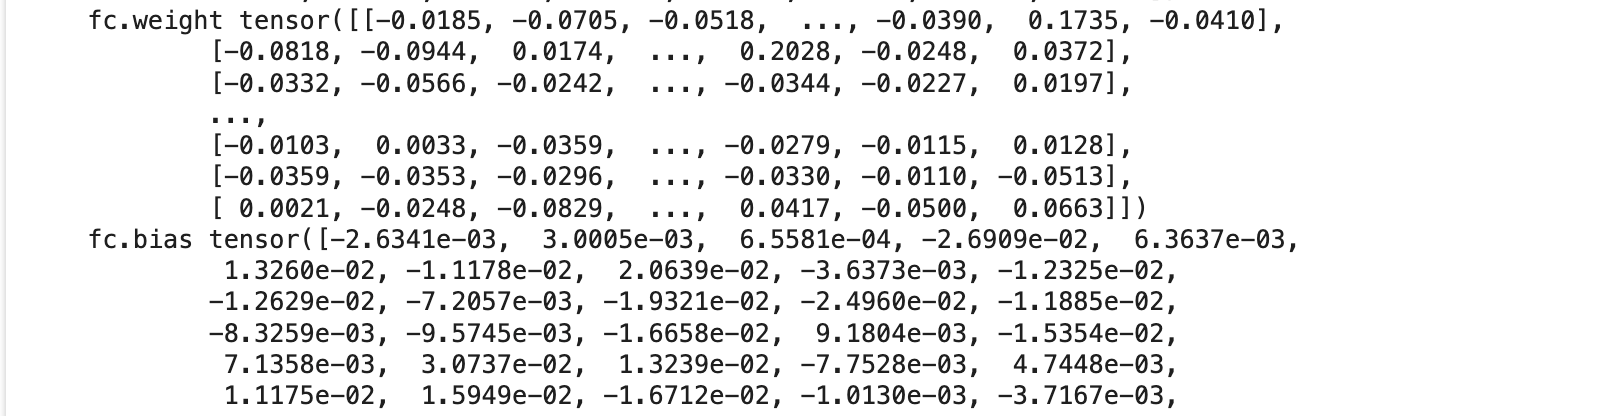
  - weight와 bias가 사용되고 있음

In [34]:
for name, param in resnet18.named_parameters(): # model.named_parameters() : 모델에 접근하여 파라미터 값 가져오기
  if param.requires_grad:
      print(name, param.data)

fc.weight tensor([[-0.0265, -0.0039, -0.0100,  ...,  0.0411, -0.0230,  0.0020],
        [ 0.0017, -0.0200,  0.0302,  ..., -0.0247, -0.0344, -0.0004]])
fc.bias tensor([-0.0134,  0.0026])


## 8. 모델 객체 생성 및 손실 함수 정의

- 모델 학습 준비를 위해 모델의 객체를 생성하고 손실 함수 정의

In [35]:
model = models.resnet18(pretrained=True) # 모델 객체 생성

for param in model.parameters(): # 모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters(): # 완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() # 손실 함수 정의

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 9. 모델 학습을 위한 함수 생성

- 데이터 준비 및 네트워크 생성이 완료되었기 때문에 이제 모델을 학습시켜야함 -> 모델 학습을 위한 함수를 생성

In [37]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders : # 데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 초라를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

    epoch_loss = running_loss/ len(dataloaders.dataset) # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss,epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/catanddog/','{0:0=2d}.pth'.format(epoch))) # 모델 재사용을 위해 저장해 둠
    print()

  time_elapsed = time.time() - since # 실행 시간(학습 시간)을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history, loss_history # 모델의 정확도와 오차를 반환

## 10. 파라미터 학습 결과를 옵티마이저에 전달

- 마지막으로 ResNet18에 추가된 완전연결층은 학습을 하도록 설정
  - 학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용함

- 아래의 결과와 같이 weight와 bias 값들이 업데이트되고 옵티마이저에 전달됨
  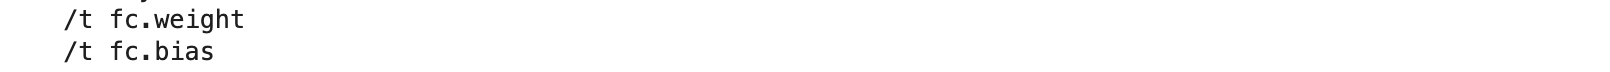

In [36]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param) # 파라미터 학습 결과를 저장
    print("/t",name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

/t fc.weight
/t fc.bias


## 11. 모델 학습

- 모델 훈련을 위해 전달되는 파라미터(모델, 학습 데이터, 손실 함수, 옵티마이저, 장치)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Loss: 0.5770 Acc: 0.7143

Epoch 1/12
----------
Loss: 0.3561 Acc: 0.8831

Epoch 2/12
----------
Loss: 0.2937 Acc: 0.8727

Epoch 3/12
----------
Loss: 0.3011 Acc: 0.8727

Epoch 4/12
----------
Loss: 0.2619 Acc: 0.8883

Epoch 5/12
----------
Loss: 0.2438 Acc: 0.9013

Epoch 6/12
----------
Loss: 0.2695 Acc: 0.8701

Epoch 7/12
----------
Loss: 0.2721 Acc: 0.9013

Epoch 8/12
----------
Loss: 0.2682 Acc: 0.8779

Epoch 9/12
----------
Loss: 0.1812 Acc: 0.9273

Epoch 10/12
----------
Loss: 0.2053 Acc: 0.9195

Epoch 11/12
----------
Loss: 0.2121 Acc: 0.9065

Epoch 12/12
----------
Loss: 0.2408 Acc: 0.8935

Training complete in 8m 27s
Best Acc: 0.927273


## 12. 테스트 데이터 호출 및 전처리

- 테스트 용도의 데이터를 이용하여 모델 정화도 측정 -> 테스트 데이터를 불러와 전처리함

In [41]:
test_path = '/content/catanddog/test'

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


## 13. 테스트 데이터 평가 함수 생성

In [42]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('catanddog/' + '*.pth')
    saved_models.sort() # 불러온 .pth 파일을 정렬
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders: # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
                outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
            preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
            running_corrects += preds.eq(labels).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 테스트 데이터의 정확도 계산
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history # 계산된 정확도 반환

- **glob** : 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용
  - 즉 '/content/catanddog/test'경로에서 pth 확장자를 갖는 파일을 가져오라는 의미
  - .pth 라는 확장자를 갖는 파일 :  훈련 데이터로 모델을 훈련시킬 때 생성된 파일
---
- **torch.max** : 주어진 텐서 배열의 최댓값이 들어 있는 index 를 반환하는 함수
  - `y_pred = [[0.2,0.7,0.8,0.4]]`라는 배열에 `torch.max(y_pred.data, 1)` 을 적용한다고 가정
  -`[0.2,0.7,0.8,0.4]`의 최댓값은 0.8 이 되며 그 인덱스는 2 -> 최종적으로 반환되는 값은 2
---
- **preds.eq(1abels)** : preds 배열과 labels가 일치하는지 검사하는 용도
  - 뒤에 사용된 sum() : 모델의 예측 결과와 정답(레이블)이 일치하는 것들의 개수 합을 숫자로 출력

## 14. 테스트 데이터를 평가 함수에 적용
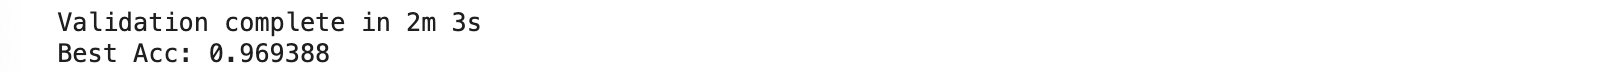
- 테스트 데이터 역시 97% 정도의 높은 정확도
  - 만약 모델의 네트워크를 개발자가 직접 구현하고 최적의 파라미터 값을 찾는다면 꽤 오랜 시간이 소요될 것
  - 하지만 사전 훈련된 모델을 사용한다면 손쉽게 모델을 학습시킬 수 있기 때문에 실무에서도 많이 사용

In [43]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['catanddog/00.pth', 'catanddog/01.pth', 'catanddog/02.pth', 'catanddog/03.pth', 'catanddog/04.pth', 'catanddog/05.pth', 'catanddog/06.pth', 'catanddog/07.pth', 'catanddog/08.pth', 'catanddog/09.pth', 'catanddog/10.pth', 'catanddog/11.pth', 'catanddog/12.pth']
Loading model catanddog/00.pth
Acc: 0.8163

Loading model catanddog/01.pth
Acc: 0.8980

Loading model catanddog/02.pth
Acc: 0.9184

Loading model catanddog/03.pth
Acc: 0.9184

Loading model catanddog/04.pth
Acc: 0.9490

Loading model catanddog/05.pth
Acc: 0.9694

Loading model catanddog/06.pth
Acc: 0.9490

Loading model catanddog/07.pth
Acc: 0.9592

Loading model catanddog/08.pth
Acc: 0.9184

Loading model catanddog/09.pth
Acc: 0.9694

Loading model catanddog/10.pth
Acc: 0.9592

Loading model catanddog/11.pth
Acc: 0.9388

Loading model catanddog/12.pth
Acc: 0.9592

Validation complete in 2m 3s
Best Acc: 0.969388


## 15. 훈련과 테스트 데이터의 정확도를 그래프로 확인

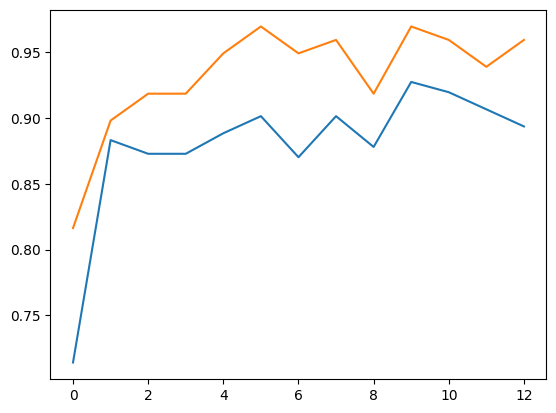

In [44]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

- 훈련과 테스트 데이터에 대해 에포크가 진행될 때마다 정확도를 출력한 결과
  - 훈련과 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100% 가까워지고 있음
  - 실제로 더 많은 에포크를 진행한다면 더욱더 100% 에 수렴하는 것을 확인할 수 있음

## 16. 훈련 데이터의 오차에 대한 그래프 확인

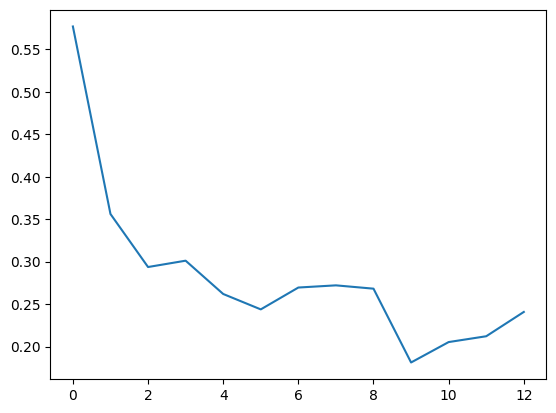

In [45]:
plt.plot(train_loss_hist)
plt.show()

- 훈련 데이터에 대해 에포크가 진행될 때마다 오차를 출력한 결과
  - 에포크가 진행될수록 오차가 낮아지고 있기 때문에 학습이 잘되었다고 할 수 있음

## 17. 예측 이미지 출력을 위한 전처리 함수

In [46]:
def im_convert(tensor):
    image=tensor.clone().detach().numpy()
    image=image.transpose(1,2,0)
    image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image=image.clip(0,1)
    return image

- **tensor.clone()** : 기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미
- **detach()** : 기존 텐서에서 기울기가 전파되지 않는 텐서
- **tensor.clone(). detach()** :  기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미
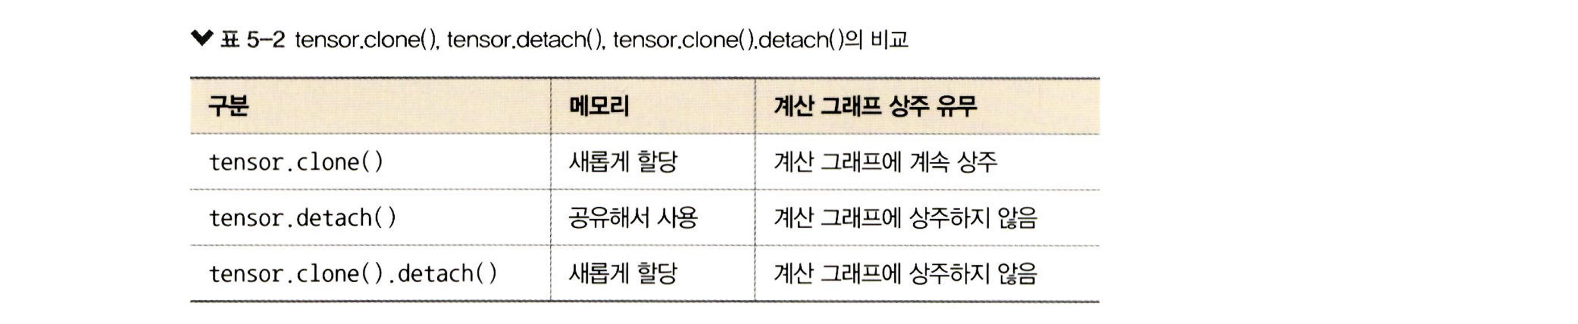

- **clip()** : 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용
  - image.clip(0, 1) : image 데이터를 0과 1 사이의 값으로 제한하겠다는 의미

## 18. 개와 고양이 예측 결과 출력

- 초록색은 개와 고양이를 정확하게 예측한 것이고, 빨간색은 예측이 잘못되었음을 의미
- 결과를 살펴보니 예측이 정확하지 않은 것을 확인할 수 있음 -> 훈련 데이터를 더 늘리고 , 에포크 횟수도 늘려 보면 더 좋은 결과를 얻을 수 있음

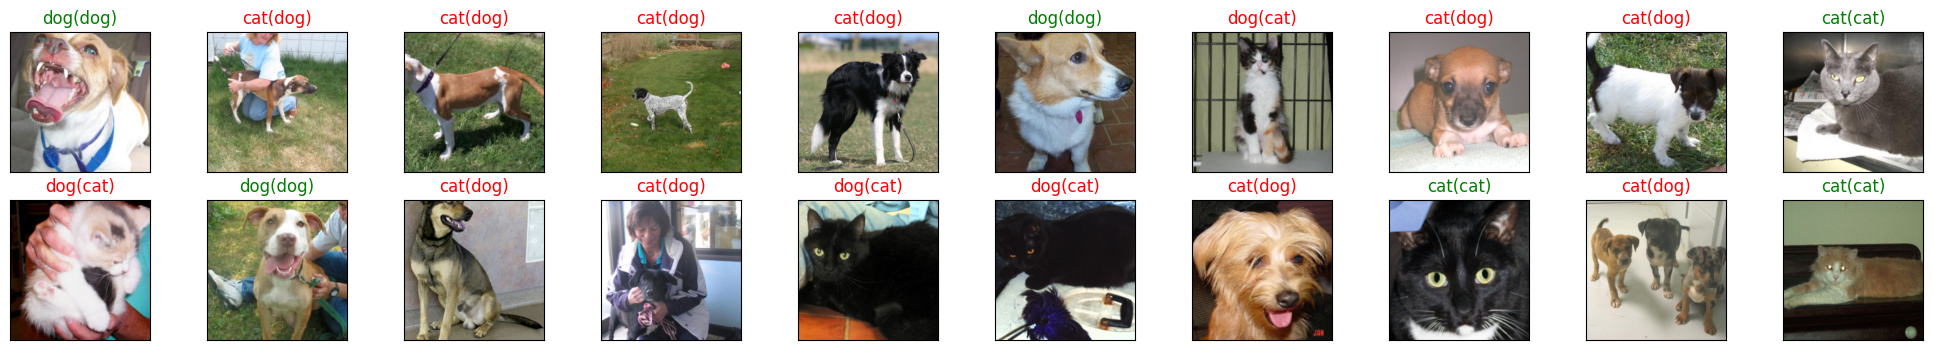

<Figure size 640x480 with 0 Axes>

In [48]:
classes = {0:'cat', 1:'dog'}

dataiter=iter(test_loader)
images, labels = next(dataiter)
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

- **add_subplot** :한 화면에 여러 개의 이미지를 담기 위해 사용
- **add_subplot(2, 10. idx+1, xticks=[], yticks=[])**
  - 첫 번째 파라미터 : 행의 수를 의미 -> 이미지를 두 줄로 출력
  - 두 번째 파라미터 : 열의 수를 의미 ->  한 줄에 열 개의 이미지를 출력
  - 세 번째 파라미터 : 인덱스를 의미 -> 행과 열을 기준으로 순차적으로 이미지를 출력
  - 네 번째 파라미터 : 틱(tick)을 삭제하겠다는 의미

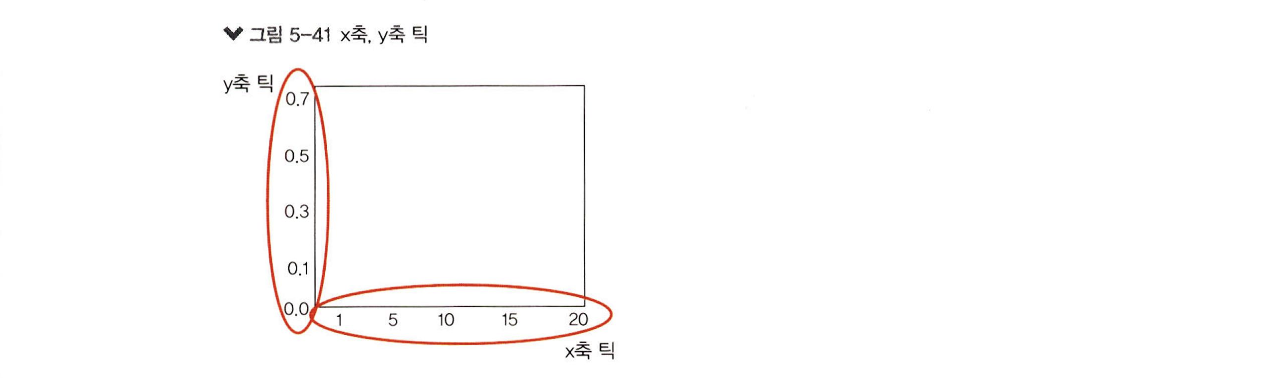

- **classes[preds[idx].item()]** : preds[idx].item()값이 classes로 정의된 0과 1중 어떤 값을 갖는지 판별하겠다는 의미
  - classes[preds [idx].item()]값이 0이면 고양이,
1이면 개로 출력
---
- 다음 그림과 같이 Figure 안에서 서브플롯(subplot)(다음 그림에서 Axes에 해당)의 위치를 조정할 때 사용
  - left, bottom, right, top으로 이미지 위치를 조정
  - hspace와 wspace를 사용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정할 수 있음


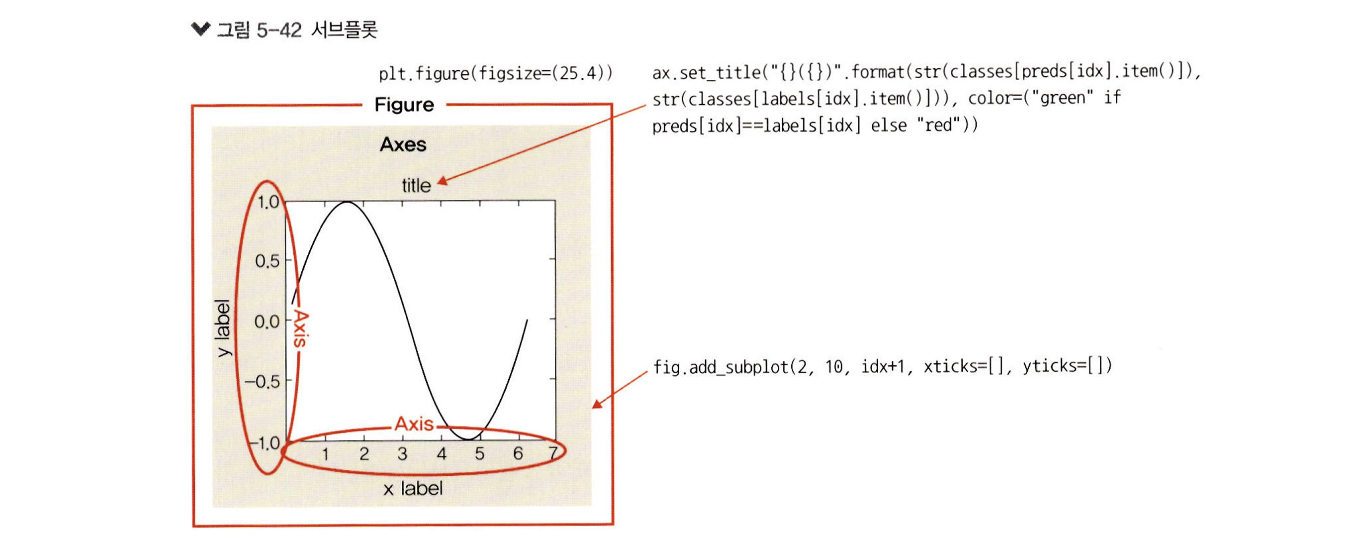